**Taller 5 - Problema de regresion con SVR**


## 1. Importar librerias necesarias para el modelo

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler


import os
from google.colab import drive

## 2. Carga de datos y preparación de sets de entrenamiento y prueba

Carga de datos división del set de datos:

In [22]:
#Cargar dataset:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# Construcción de X (features)
X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])

# Construcción de y (target)
y = raw_df.values[1::2, 2]

# Crear DataFrame con nombres de columnas
columns = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS',
           'RAD','TAX','PTRATIO','B','LSTAT']

data = pd.DataFrame(X, columns=columns)
data['MEDV'] = y

print(data.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


In [23]:
# Dividimos el set de entrenamiento y el de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##3. Ejemplo Modelo SVR

Modelo inicial o linea base de comparación

Mean Squared Error: 44.33500513460085
R^2 Score: 0.3954354565661058


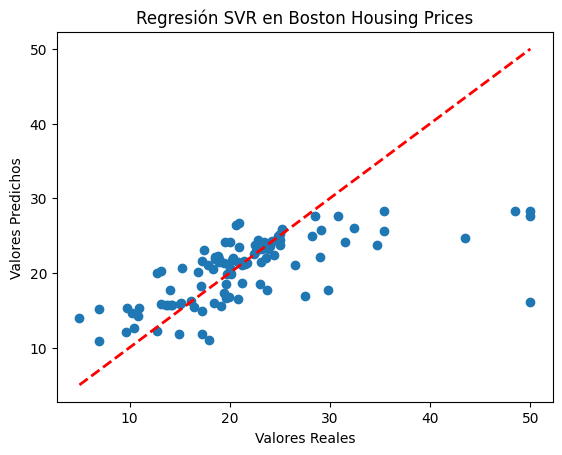

In [24]:
# Creación del modelo SVR
svr = SVR(kernel='rbf', C=10.0, epsilon=0.2)

#Entrenamiento del modelo
svr.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = svr.predict(X_test)

# Evaluar el rendimiento del modelo
mse = mean_squared_error(y_test, y_pred)
r2test = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2test}")

# Graficar resultados
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Regresión SVR en Boston Housing Prices')
plt.show()

Analisis modelo por modelo. Se prepara un GridSearch para cada uno de los modelos a evaluar: lineal, polinómico, gaussiano y sigmoide. Para cada uno de éstos se busca el mejor conjunto de hiperparámetros, tomando como base el resultado de su R2:

Kernel utilizado: linear
Mejores hiperparámetros: {'C': 10, 'epsilon': 0.1}
MSE Test: 29.6481
R^2 Test: 0.5957


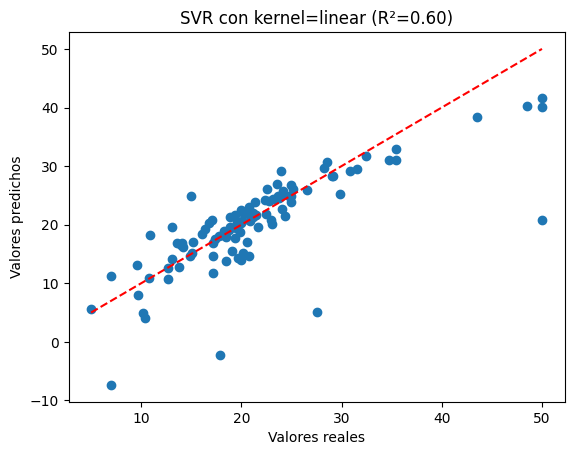

Kernel utilizado: poly
Mejores hiperparámetros: {'C': 10, 'epsilon': 0.5}
MSE Test: 42.2842
R^2 Test: 0.4234


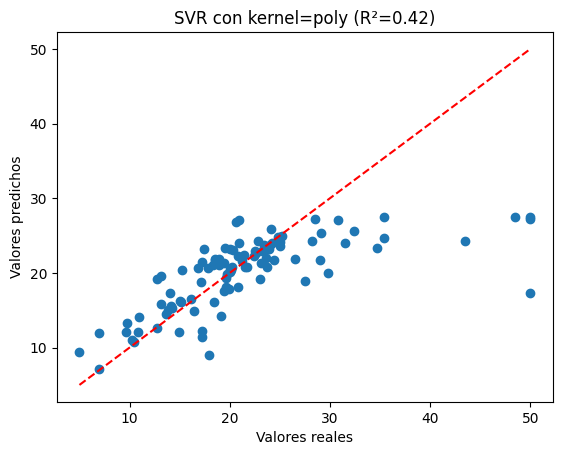

Kernel utilizado: rbf
Mejores hiperparámetros: {'C': 10, 'epsilon': 0.3}
MSE Test: 44.3622
R^2 Test: 0.3951


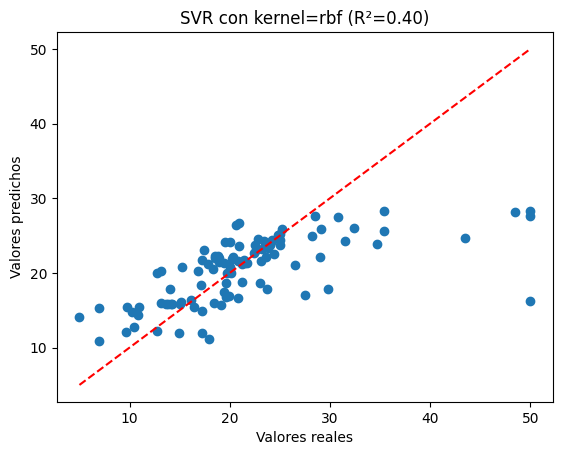

Kernel utilizado: sigmoid
Mejores hiperparámetros: {'C': 1, 'epsilon': 0.4}
MSE Test: 67.7890
R^2 Test: 0.0756


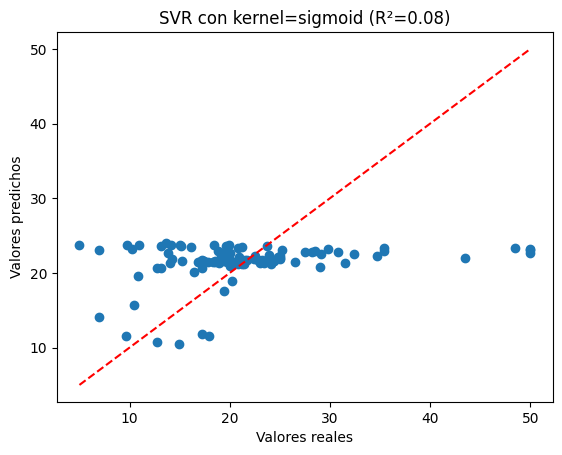

In [27]:
# Parámetros a probar
param_grid = {
    'C': [0.1, 1, 5, 10],
    'epsilon': [0.1, 0.2, 0.3, 0.4, 0.5]
}

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
resultados = {}

for k in kernels:
    print(f"Kernel utilizado: {k}")
    svr = SVR(kernel=k)
    grid = GridSearchCV(svr, param_grid, scoring='r2', cv=5, n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    # Métricas por modelo
    mse = mean_squared_error(y_test, y_pred)
    r2test = r2_score(y_test, y_pred)

    print("Mejores hiperparámetros:", grid.best_params_)
    print(f"MSE Test: {mse:.4f}")
    print(f"R^2 Test: {r2test:.4f}")

    # Guardar resultados
    resultados[k] = (grid.best_params_, mse, r2test)

    # Gráfica de dispersión
    plt.scatter(y_test, y_pred)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
    plt.xlabel("Valores reales")
    plt.ylabel("Valores predichos")
    plt.title(f"SVR con kernel={k} (R²={r2test:.2f})")
    plt.show()

##4. Análisis de resultados y conclusiones

**Preguntas:**
1. ¿Cómo afecta la variación de estos hiparámetros en el desempeño del modelo? Justifique su respuesta para el C, los diferentes kernel empleado y epsilon

Para 3 de los cuatro modelos (lineal, polinómico y gaussiano) el mejor modelo se dio con un C grande es decir con poca regularización. Un C pequeño fuerza un modelo mas simple, mientras que un C mayor penaliza mas los errores. Por lo tanto, se puede concluir que el set de datos no es principalmente ruidoso, es decir que a pesar que los modelos tratan de ajustarse mejor al entrenamiento, no aumentan la varianza de manera considerable.

Para el caso del hiperparámetro epsilon este no presenta un comportamiento homogeneo y varía según cada modelo debido a que cada kernel maneja la complejidad y suavidad de la predicción en forma diferente de ahí que la tolerancia óptima a errores, que se controla por medio de este parámetro, cambie. Por ejemplo, para el caso del modelo lineal un epsilon pequeño (0.1) ayuda a capturar variaciones sin volverse inestable, muy diferente al caso polinómico (0.5) necesita un parámetro mayor para no sobreajustar.   


2. ¿Cuál fué el modelo con mejor desempeño? ¿Cómo se refleja esto en la gráfica de dispersión?

El modelo con mejor desempeño encontrado es el modelo lineal. Lo anterior puede explicarse por varios factores:

El set de datos presenta un comportamiento bastante lineal entre las características del inmueble y su precio final, es decir una casa con mas habitaciones presentará un mayor precio. Esto mismo aplica para otras variables como el área de la propiedad entre otros parámetros. De ahí que un kernel lineal funciona mejor ya que captura mejor el comportamiento de los datos frente a la variable objetivo. En caso que los datos hubieran tenido relaciones mas complejas, por ejemplo curvas o no linealidades, los modelos polinómicos o gaussianos hubieran superado al lineal. Por lo tanto se puede concluir que la superficie de decisión que mejor ajusta los datos es un hiperplano debido a que la variable objetivo se puede caracterizar como una combinación lineal.

El SVR lineal es suficiente para el problema, es decir kernels mas elaborados tenderán a aprender de más a partir del set de entrenamiento, generando de esta manera mayor sobreajuste que un modelo mas simple. De otro lado kernels no lineales aumentan su dimensionalidad implícitamente lo cual puede ser útil cuando la relación entre las características y variable objetivo no es necesariamente lineal.  

Con respecto a las gráficas de dispersión, al tratarse de gráficas que muestran el comportamiento real versus predicho, estas deberían mostrar una dispersión de puntos en forma de linea (y = x) en caso de una predicción perfecta. Con eso en mente, vemos que la gráfica que mejor presenta este comportamiento es precisamente el modelo lineal seguido por los modelos polinómico, gaussiano y sigmoide; este último vemos como la dispersión de puntos predichos se concentra en un un rango muy pequeño de valores, no capturando la relación por ende con una muy baja capacidad de generalización, lo cual se confirma con su pobre resultado de R2.